# DSCI 552: HW2
- **Name:** Pavanitha Manche
- **USC ID:** 2866839249
- **GitHub Username:** Pavanitha09

## 1. Combined Cycle Power Plant Data Set


In [1]:
#Package Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

### 1(a) Data Loading


In [2]:
data_path = '../data/CCPP/Folds5x2_pp.xlsx'
df = pd.read_excel(data_path, sheet_name=0)

# Rename columns to match mathematical notation in the assignment
df = df.rename(columns={'AT': 'T', 'PE': 'EP'})

print(f"Dataset successfully loaded {df.shape}")
display(df.head())

Dataset successfully loaded (9568, 5)


,T,V,AP,RH,EP
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### 1(b) Exploring the Data

#### (i)Rows and Columns 

In [3]:

n_rows, n_cols = df.shape
response = 'EP'
predictor_cols = [c for c in df.columns if c != response]

print(f"Number of rows:    {n_rows}")
print(f"Number of columns: {n_cols}  ({len(predictor_cols)} predictors + 1 response)\n")
print(f"Each of the {n_rows} rows is one hourly-average observation of the plant's ambient "
      f"conditions and net electrical output, recorded at full load over 2006-2011.\n")

# What each column represents:
column_info = {
    'T':  ('Ambient Temperature', 'deg C', 'Predictor (independent variable)'),
    'V':  ('Exhaust Vacuum', 'cm Hg', 'Predictor (independent variable)'),
    'AP': ('Ambient Pressure', 'millibar', 'Predictor (independent variable)'),
    'RH': ('Relative Humidity', '%', 'Predictor (independent variable)'),
    'EP': ('Net Hourly Electrical Energy Output', 'MW', 'Response (dependent variable)'),
}
columns_table = pd.DataFrame(
    [{'Column': c,
      'Represents': column_info[c][0],
      'Unit': column_info[c][1],
      'Role': column_info[c][2],
      'dtype': str(df[c].dtype),
      'Non-null': int(df[c].notna().sum()),
      'Missing': int(df[c].isna().sum())} for c in df.columns]
).set_index('Column')
display(columns_table)


Number of rows:    9568
Number of columns: 5  (4 predictors + 1 response)

Each of the 9568 rows is one hourly-average observation of the plant's ambient conditions and net electrical output, recorded at full load over 2006-2011.



,Represents,Unit,Role,dtype,Non-null,Missing
Column,,,,,,
T,Ambient Temperature,deg C,Predictor (independent variable),float64,9568,0
V,Exhaust Vacuum,cm Hg,Predictor (independent variable),float64,9568,0
AP,Ambient Pressure,millibar,Predictor (independent variable),float64,9568,0
RH,Relative Humidity,%,Predictor (independent variable),float64,9568,0
EP,Net Hourly Electrical Energy Output,MW,Response (dependent variable),float64,9568,0


#### (ii) Pairwise scatterplots of all variables, and findings

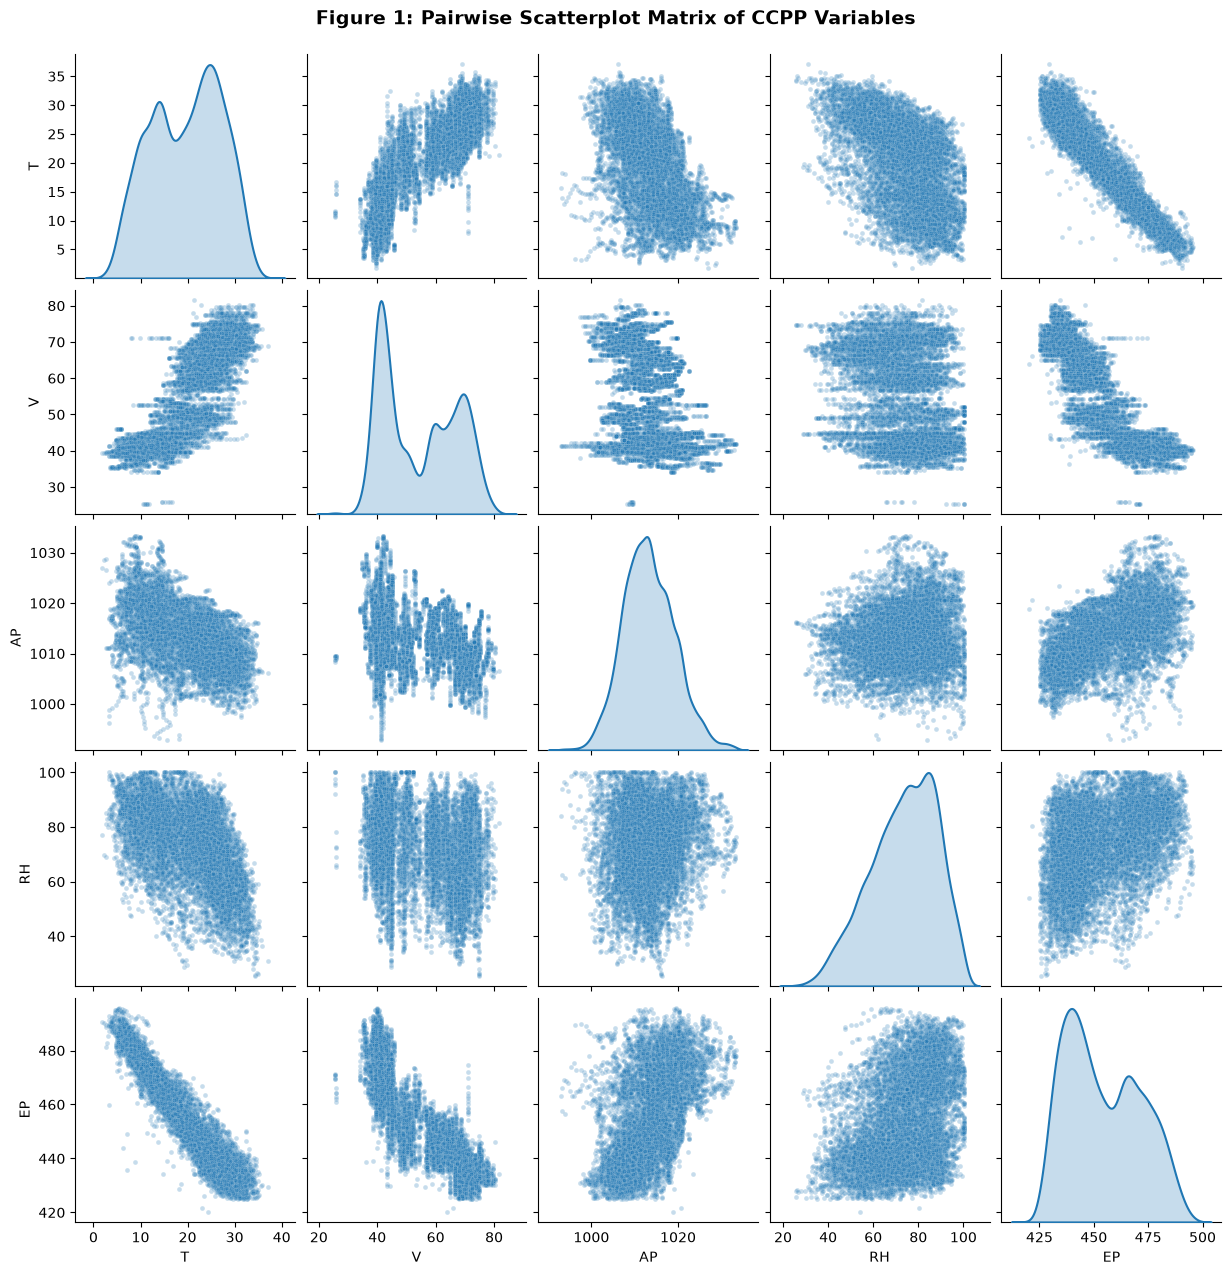

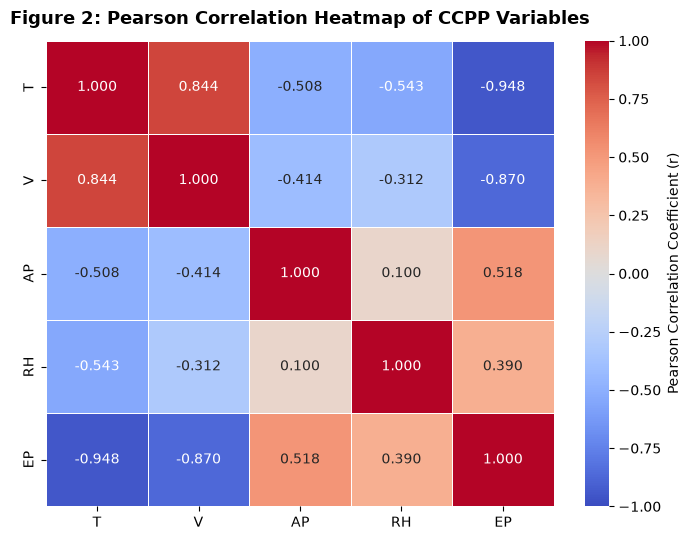

In [4]:
pairplot_fig = sns.pairplot(
    df[['T', 'V', 'AP', 'RH', 'EP']],
    diag_kind='kde',
    plot_kws={'alpha': 0.25, 's': 12, 'color': '#1f77b4'},
    diag_kws={'color': '#1f77b4', 'linewidth': 1.5}
)
pairplot_fig.fig.suptitle("Figure 1: Pairwise Scatterplot Matrix of CCPP Variables", y=1.02, fontsize=14, weight='bold')
plt.show()

corr_matrix = df.corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Pearson Correlation Coefficient (r)'},
    linewidths=0.5
)
plt.title("Figure 2: Pearson Correlation Heatmap of CCPP Variables", fontsize=13, weight='bold', pad=12)
plt.tight_layout()
plt.show()


In [5]:
# 1(b)ii Findings Computed from the Data
# Correlation of each predictor with the response, strongest first
r_ep = corr_matrix.loc[predictor_cols, 'EP'].sort_values(key=abs, ascending=False)
print("Correlation of each predictor with EP (strongest first):")
for p, r in r_ep.items():
    print(f"  {p:>2}: r = {r:+.3f}  ->  higher {p} goes with {'lower' if r < 0 else 'higher'} EP")

# Strongly correlated predictor pairs (possible collinearity)
print("\nStrongly correlated predictor pairs (|r| >= 0.7):")
for i, a in enumerate(predictor_cols):
    for b in predictor_cols[i + 1:]:
        if abs(corr_matrix.loc[a, b]) >= 0.7:
            print(f"  {a} & {b}: r = {corr_matrix.loc[a, b]:+.3f}")

Correlation of each predictor with EP (strongest first):
   T: r = -0.948  ->  higher T goes with lower EP
   V: r = -0.870  ->  higher V goes with lower EP
  AP: r = +0.518  ->  higher AP goes with higher EP
  RH: r = +0.390  ->  higher RH goes with higher EP

Strongly correlated predictor pairs (|r| >= 0.7):
  T & V: r = +0.844


#### Findings
- **Temperature matters most.** When it gets hotter, the plant produces less power. Of all the plots against $EP$, the $T$ plot is the tightest and closest to a straight line (with a slight bend). Hot air is thinner, so the gas turbine takes in less air and produces less energy.
- **Exhaust vacuum works the same way.** Higher $V$ goes with lower output. The $V$ points also form separate clumps, probably because the plant tends to run at a few typical vacuum levels.
- **Pressure and humidity matter much less.** Both go up with output, but their plots are wide, scattered clouds. On their own, neither predicts $EP$ well.
- **$T$ and $V$ move together.** On hot days the condenser cools less well, so $V$ rises too. Because the two carry overlapping information, their coefficients will change once both are in the same regression (parts c–e).
- **Distributions (the plots on the diagonal).** $T$ and $V$ each have more than one peak, which probably reflects different seasons or operating modes. Humidity bunches up near its 100% limit, while pressure looks like a fairly normal bell curve.

#### (iii) Mean, median, range, first and third quartiles, and interquartile range of each variable


In [6]:
summary_table = pd.DataFrame({
    'Mean': df.mean(),
    'Median': df.median(),
    'Range (Max - Min)': df.max() - df.min(),
    'Q1 (25%)': df.quantile(0.25),
    'Q3 (75%)': df.quantile(0.75),
    'IQR (Q3 - Q1)': df.quantile(0.75) - df.quantile(0.25),
    'Min': df.min(),
    'Max': df.max(),
    'Std Dev': df.std(),
})
summary_table.index.name = 'Variable'
print("Summary Statistics for CCPP Variables")
display(summary_table.round(3))

for c in df.columns:
    row = summary_table.loc[c]
    gap = row['Mean'] - row['Median']
    lean = 'mean > median (right tail)' if gap > 0 else 'mean < median (left tail)'
    print(f"  - {c}: median = {row['Median']:.2f}, IQR = {row['IQR (Q3 - Q1)']:.2f}, "
          f"range = {row['Range (Max - Min)']:.2f}; {lean}")


Summary Statistics for CCPP Variables


,Mean,Median,Range (Max - Min),Q1 (25%),Q3 (75%),IQR (Q3 - Q1),Min,Max,Std Dev
Variable,,,,,,,,,
T,19.651,20.345,35.30,13.510,25.72,12.210,1.81,37.11,7.452
V,54.306,52.080,56.20,41.740,66.54,24.800,25.36,81.56,12.708
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160,992.89,1033.30,5.939
RH,73.309,74.975,74.60,63.328,84.83,21.502,25.56,100.16,14.600
EP,454.365,451.550,75.50,439.750,468.43,28.680,420.26,495.76,17.067


  - T: median = 20.34, IQR = 12.21, range = 35.30; mean < median (left tail)
  - V: median = 52.08, IQR = 24.80, range = 56.20; mean > median (right tail)
  - AP: median = 1012.94, IQR = 8.16, range = 40.41; mean > median (right tail)
  - RH: median = 74.97, IQR = 21.50, range = 74.60; mean < median (left tail)
  - EP: median = 451.55, IQR = 28.68, range = 75.50; mean > median (right tail)


### 1(c) Simple Linear Regression
For each predictor we fit $EP = \beta_0 + \beta_1 X + \epsilon$ and test $H_0: \beta_1 = 0$.

In [7]:
predictors = ['T', 'V', 'AP', 'RH']
simple_models = {p: smf.ols(f'EP ~ {p}', data=df).fit() for p in predictors}

simple_results = pd.DataFrame({
    'Intercept': [simple_models[p].params['Intercept'] for p in predictors],
    'Slope': [simple_models[p].params[p] for p in predictors],
    't-statistic': [simple_models[p].tvalues[p] for p in predictors],
    'p-value': [simple_models[p].pvalues[p] for p in predictors],
    'R-squared': [simple_models[p].rsquared for p in predictors],
}, index=predictors)
display(simple_results.round(4))

,Intercept,Slope,t-statistic,p-value,R-squared
T,497.0341,-2.1713,-291.7152,0.0,0.8989
V,517.8015,-1.1681,-172.4015,0.0,0.7565
AP,-1055.2610,1.4899,59.2962,0.0,0.2688
RH,420.9618,0.4557,41.3987,0.0,0.1519


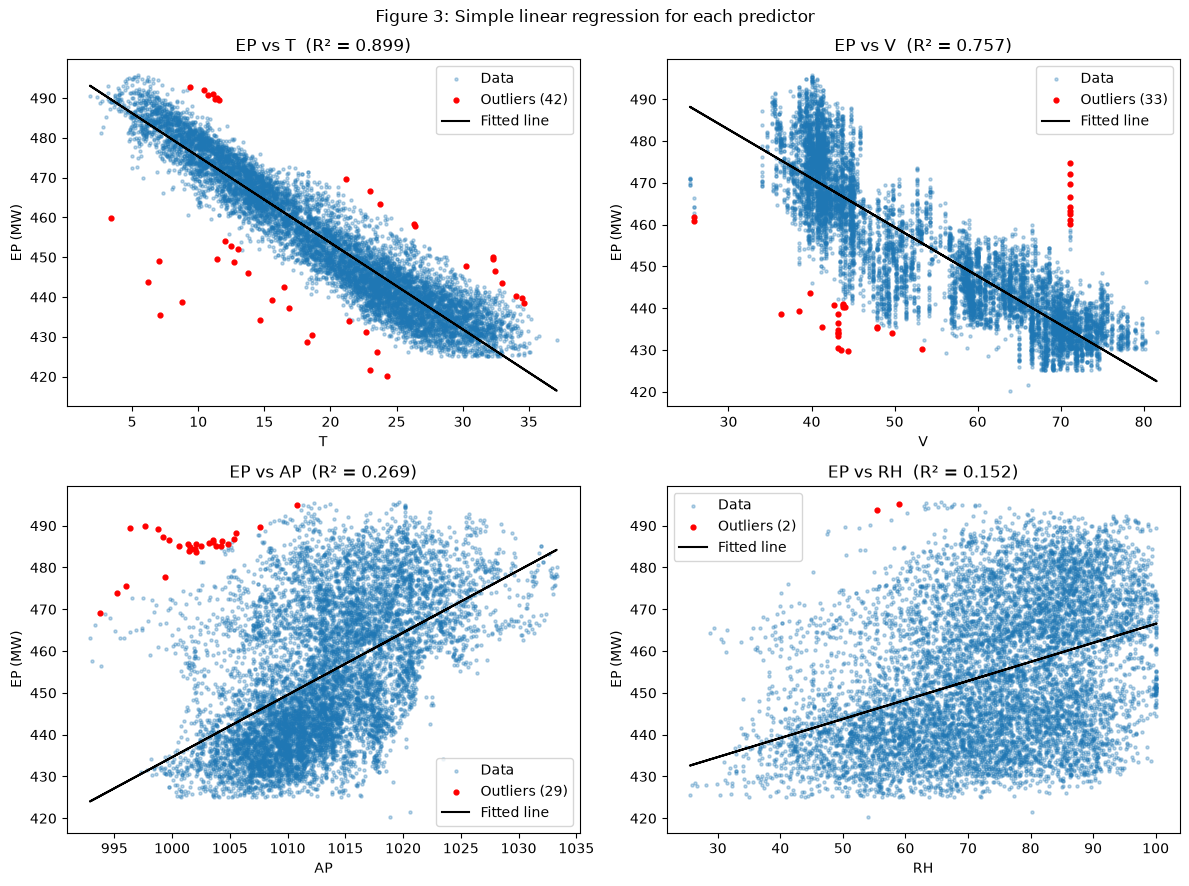

In [8]:
# Scatter plot with fitted line; points with |studentized residual| > 3 are marked as outliers
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, p in zip(axes.flatten(), predictors):
    model = simple_models[p]
    outlier = np.abs(model.get_influence().resid_studentized_internal) > 3
    ax.scatter(df[p], df['EP'], s=5, alpha=0.3, label='Data')
    ax.scatter(df[p][outlier], df['EP'][outlier], s=12, color='red', label=f'Outliers ({outlier.sum()})')
    ax.plot(df[p], model.fittedvalues, color='black', label='Fitted line')
    ax.set_title(f'EP vs {p}  (R² = {model.rsquared:.3f})')
    ax.set_xlabel(p)
    ax.set_ylabel('EP (MW)')
    ax.legend()
plt.suptitle('Figure 3: Simple linear regression for each predictor')
plt.tight_layout()
plt.show()

In [9]:
# Does removing the outliers change the fit?
rows = []
for p in predictors:
    model = simple_models[p]
    keep = np.abs(model.get_influence().resid_studentized_internal) <= 3
    refit = smf.ols(f'EP ~ {p}', data=df[keep]).fit()
    rows.append([p, (~keep).sum(), model.params[p], refit.params[p], model.rsquared, refit.rsquared])

outlier_table = pd.DataFrame(rows, columns=['Predictor', 'Outliers', 'Slope (all data)', 'Slope (no outliers)',
                                            'R² (all data)', 'R² (no outliers)']).set_index('Predictor')
display(outlier_table.round(4))

,Outliers,Slope (all data),Slope (no outliers),R² (all data),R² (no outliers)
Predictor,,,,,
T,42,-2.1713,-2.1802,0.8989,0.9064
V,33,-1.1681,-1.1769,0.7565,0.7670
AP,29,1.4899,1.5390,0.2688,0.2860
RH,2,0.4557,0.4564,0.1519,0.1526


**Results:** 
- Each predictor on its own is related to $EP$. $T$ and $V$ have negative slopes (hotter air or a higher vacuum reading means less power), while $AP$ and $RH$ have positive slopes. $T$ alone explains about 90% of the variation in $EP$ ($R^2 = 0.899$), $V$ about 76%, $AP$ about 27% and $RH$ only about 15%.
- **Statistical significance:** All four p-values are essentially 0, so **every predictor has a statistically significant association with $EP$**. Figure 3 backs this up: each fitted line has a clear slope, and the fit is tightest for $T$ and $V$.
- **Outliers:** Using $|\text{studentized residual}| > 3$, there are 42 outliers for $T$, 33 for $V$, 29 for $AP$ and 2 for $RH$ (red points in Figure 3). Removing them barely changes the slopes, and $R^2$ only goes up slightly (table above). These points look like normal operating conditions rather than recording errors, so **we do not remove them**.

### 1(d) Multiple Linear Regression

In [10]:
multi_model = smf.ols('EP ~ T + V + AP + RH', data=df).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:48:50   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

**Result:**
- The model with all four predictors explains about 92.9% of the variation in $EP$ ($R^2 = 0.929$), which is better than any single predictor alone.
- All four p-values are below 0.001, so **we can reject $H_0: \beta_j = 0$ for every predictor ($T$, $V$, $AP$ and $RH$)**. Each one still adds information about $EP$ when the other three are in the model.

### 1(e) Comparing 1(c) with 1(d)

,Simple (1c),Multiple (1d)
T,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


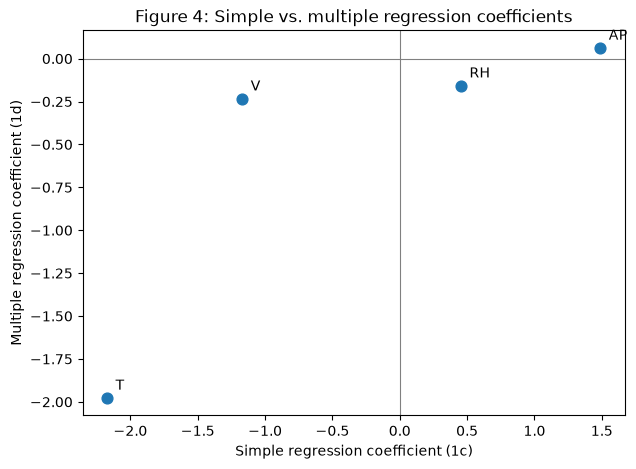

In [11]:
coefs = pd.DataFrame({
    'Simple (1c)': [simple_models[p].params[p] for p in predictors],
    'Multiple (1d)': [multi_model.params[p] for p in predictors],
}, index=predictors)
display(coefs.round(4))

plt.figure(figsize=(7, 5))
plt.scatter(coefs['Simple (1c)'], coefs['Multiple (1d)'], s=60)
for p in predictors:
    plt.annotate(p, (coefs.loc[p, 'Simple (1c)'], coefs.loc[p, 'Multiple (1d)']),
                 xytext=(6, 6), textcoords='offset points')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('Simple regression coefficient (1c)')
plt.ylabel('Multiple regression coefficient (1d)')
plt.title('Figure 4: Simple vs. multiple regression coefficients')
plt.show()

**Results:** The coefficients change quite a lot once all predictors are in the same model:
- $T$ barely changes ($-2.17 \to -1.98$). It is the main driver of $EP$ either way.
- $V$ and $AP$ shrink a lot ($-1.17 \to -0.23$ and $1.49 \to 0.06$). On their own they partly stand in for temperature, since $V$ rises and $AP$ falls on hot days. Once $T$ is in the model, their own effect is much smaller.
- $RH$ even flips sign ($+0.46 \to -0.16$). Humid days tend to be cooler days, so on its own humidity seems to help. After accounting for temperature, higher humidity slightly lowers output.

This happens because the predictors are correlated with each other (especially $T$ and $V$), so a simple regression mixes each predictor's own effect with the effects of the variables it moves with.

### 1(f) Nonlinear Association

In [12]:
# Fit EP = b0 + b1*X + b2*X^2 + b3*X^3 for each predictor.
df_centered = df[predictors] - df[predictors].mean()
df_centered['EP'] = df['EP']

rows = []
for p in predictors:
    cubic = smf.ols(f'EP ~ {p} + I({p}**2) + I({p}**3)', data=df_centered).fit()
    linear = smf.ols(f'EP ~ {p}', data=df_centered).fit()
    f_stat, f_pvalue, _ = cubic.compare_f_test(linear)   # H0: b2 = b3 = 0 (no nonlinearity)
    rows.append([p, cubic.pvalues.iloc[2], cubic.pvalues.iloc[3], f_pvalue,
                 simple_models[p].rsquared, cubic.rsquared])

cubic_table = pd.DataFrame(rows, columns=['Predictor', 'p-value X²', 'p-value X³', 'p-value X² & X³ jointly',
                                          'R² (linear)', 'R² (cubic)']).set_index('Predictor')
display(cubic_table.map(lambda v: f'{v:.2e}' if v < 0.001 else f'{v:.4f}'))

,p-value X²,p-value X³,p-value X² & X³ jointly,R² (linear),R² (cubic)
Predictor,,,,,
T,3.31e-231,3.65e-110,3.48e-285,0.8989,0.9119
V,8.98e-131,0.0137,7.04e-165,0.7565,0.7750
AP,2.19e-46,2.12e-67,4.21e-84,0.2688,0.2975
RH,0.1014,1.44e-05,3.80e-05,0.1519,0.1537


**Results**:  Yes, there is evidence of a nonlinear association for all four predictors.
- The column **"p-value X² & X³ jointly"** tests $H_0: \beta_2 = \beta_3 = 0$, i.e. whether the relationship is really just a straight line. It is far below 0.05 for every predictor, so the cubic model fits significantly better than the straight line in each case. The $X^3$ p-value is also below 0.05 for all four.
- **$T$, $V$ and $AP$:** The nonlinearity is strong. $R^2$ goes up noticeably compared with the straight-line fit ($T$: 0.899 → 0.912, $V$: 0.757 → 0.775, $AP$: 0.269 → 0.298).
- **$RH$:** The joint test ($p \approx 4 \times 10^{-5}$) is significant, but $R^2$ only moves from 0.152 to 0.154. So the nonlinearity for $RH$ is statistically significant but too small to matter in practice.
- The p-value of $X^2$ on its own depends on the centering (for example 0.10 for $RH$), so the conclusions are based on the joint test and the $X^3$ term instead.

### 1(g) Interactions of Predictors


In [13]:
#Full model with all 4 predictors and all 6 pairwise interaction terms.
interaction_model = smf.ols('EP ~ (T + V + AP + RH)**2', data=df).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     EP   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:48:50   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

**Answers for 1(g):** Yes, some interactions are significant. At the 5% level:
- **Significant:** $T{:}V$, $T{:}RH$ and $V{:}AP$ (all $p < 0.001$), and $AP{:}RH$ ($p = 0.034$).
- **Not significant:** $T{:}AP$ ($p = 0.452$) and $V{:}RH$ ($p = 0.086$).

$R^2$ goes up from 0.929 (no interactions) to 0.936.

### 1(h) Improving the Model

In [14]:
# Add squared terms, then split 70/30
df_h = df.copy()
for p in predictors:
    df_h[p + '2'] = df[p] ** 2
train_df, test_df = train_test_split(df_h, test_size=0.3, random_state=42)

def train_test_mse(model):
    return (mean_squared_error(train_df['EP'], model.predict(train_df)),
            mean_squared_error(test_df['EP'], model.predict(test_df)))

# Model 1: all 4 predictors
linear_model = smf.ols('EP ~ T + V + AP + RH', data=train_df).fit()

# Model 2: all quadratic + interaction terms, then backward elimination by p-value
terms = predictors + [p + '2' for p in predictors] + \
        [f'{a}:{b}' for i, a in enumerate(predictors) for b in predictors[i + 1:]]
while True:
    model = smf.ols('EP ~ ' + ' + '.join(terms), data=train_df).fit()
    # main effects that still appear in a squared or interaction term cannot be removed
    in_use = {v for t in terms if t not in predictors for v in t.replace('2', '').split(':')}
    pvals = model.pvalues[[t for t in terms if t not in in_use]]
    if pvals.max() <= 0.05:
        break
    print(f'Removed {pvals.idxmax()} (p = {pvals.max():.3f})')
    terms.remove(pvals.idxmax())
improved_model = model
print('Terms kept:', terms)

results_h = pd.DataFrame([train_test_mse(linear_model), train_test_mse(improved_model)],
                         index=['Linear (4 predictors)', 'Quadratic + interactions (pruned)'],
                         columns=['Train MSE', 'Test MSE'])
display(results_h.round(3))

Removed V:RH (p = 0.867)
Removed V2 (p = 0.608)
Removed V:AP (p = 0.358)
Terms kept: ['T', 'V', 'AP', 'RH', 'T2', 'AP2', 'RH2', 'T:V', 'T:AP', 'T:RH', 'AP:RH']


,Train MSE,Test MSE
Linear (4 predictors),20.581,21.24
Quadratic + interactions (pruned),17.891,18.66


**Results :** Yes, the model can be improved.
- Backward elimination removed $V{:}RH$, $V^2$ and $V{:}AP$. The final model keeps all four main effects, $T^2$, $AP^2$, $RH^2$ and the interactions $T{:}V$, $T{:}AP$, $T{:}RH$ and $AP{:}RH$.
- The plain linear model has train MSE 20.58 and test MSE 21.24. The improved model lowers these to 17.89 (train) and 18.66 (test), about 12% less test error.
- Train and test MSEs are close for both models, so the extra terms are not overfitting.

### 1(i) KNN Regression

In [15]:
X_train, X_test = train_df[predictors], test_df[predictors]
y_train, y_test = train_df['EP'], test_df['EP']
scaler = StandardScaler().fit(X_train)

feature_sets = {'Raw': (X_train, X_test),
                'Normalized': (scaler.transform(X_train), scaler.transform(X_test))}
k_values = np.arange(1, 101)
knn_errors = {}

for name, (Xtr, Xte) in feature_sets.items():
    train_mse, test_mse = [], []
    for k in k_values:
        knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr, y_train)
        train_mse.append(mean_squared_error(y_train, knn.predict(Xtr)))
        test_mse.append(mean_squared_error(y_test, knn.predict(Xte)))
    knn_errors[name] = (train_mse, test_mse)
    best = np.argmin(test_mse)
    print(f'{name} features: best k = {k_values[best]}, train MSE = {train_mse[best]:.3f}, test MSE = {test_mse[best]:.3f}')

Raw features: best k = 5, train MSE = 10.601, test MSE = 15.727
Normalized features: best k = 4, train MSE = 8.591, test MSE = 14.306


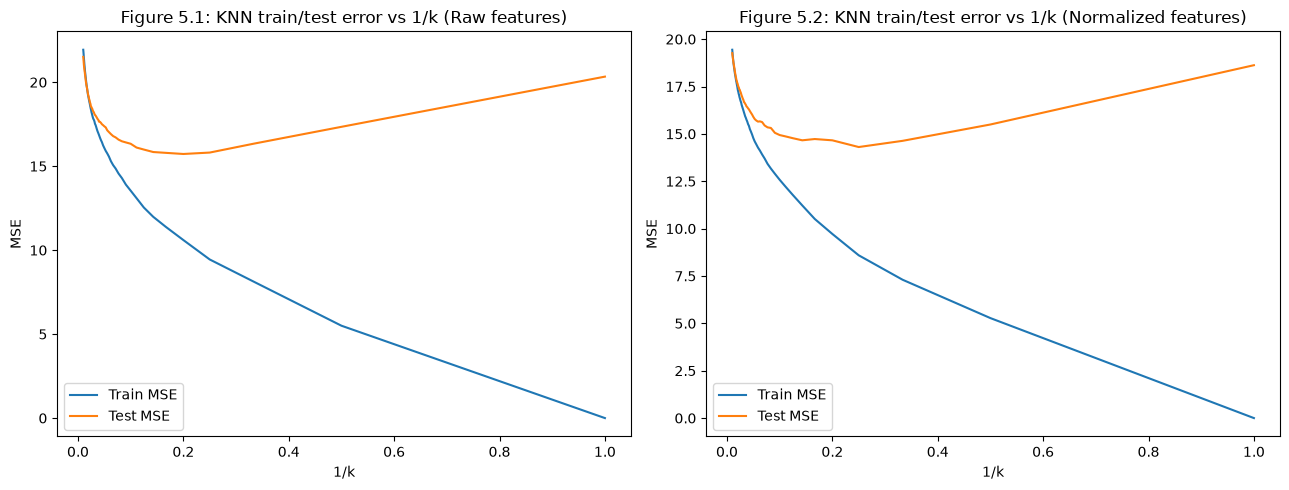

In [16]:
#Plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (ax, (name, (train_mse, test_mse))) in enumerate(zip(axes, knn_errors.items()), start=1):
    ax.plot(1 / k_values, train_mse, label='Train MSE')
    ax.plot(1 / k_values, test_mse, label='Test MSE')
    ax.set_xlabel('1/k')
    ax.set_ylabel('MSE')
    ax.set_title(f'Figure 5.{i}: KNN train/test error vs 1/k ({name} features)')
    ax.legend()
plt.tight_layout()
plt.show()

**Results:**
- **Best k:** $k = 5$ with raw features (test MSE 15.73) and $k = 4$ with normalized features (test MSE 14.31), as printed above.
- **Error vs. $1/k$ (Figure 5):** Moving to the right means a smaller $k$, i.e. a more flexible model. The training error keeps dropping and reaches 0 at $k = 1$, where every point is its own nearest neighbor. The test error first drops and then rises again once the model starts to overfit, which is the usual bias–variance trade-off. The best $k$ sits at the bottom of that test-error curve.
- **Raw vs. normalized:** Normalizing gives the lower test error. Without scaling, the features with a bigger spread ($RH$ and $V$) dominate the distance between points, and the most important feature, $T$, gets too little weight. Putting all features on the same scale fixes this.

### 1(j) KNN vs. Linear Regression

In [17]:
comparison = pd.DataFrame({'Test MSE': [
    results_h.loc['Linear (4 predictors)', 'Test MSE'],
    results_h.loc['Quadratic + interactions (pruned)', 'Test MSE'],
    min(knn_errors['Raw'][1]),
    min(knn_errors['Normalized'][1]),
]}, index=['Linear (4 predictors)', 'Quadratic + interactions (pruned)',
           'KNN, raw features', 'KNN, normalized features'])
display(comparison.round(3))

,Test MSE
Linear (4 predictors),21.240
Quadratic + interactions (pruned),18.660
"KNN, raw features",15.727
"KNN, normalized features",14.306


**Results:** The linear regression model with the smallest test error is the improved quadratic + interaction model from 1(h) (test MSE 18.66). KNN with normalized features does better, with a test MSE of 14.31, about 23% lower.

KNN wins here because there are only 4 predictors and thousands of data points, so every point has close neighbors to average over. KNN can also follow the curved relationships and interactions found in 1(f) and 1(g) without being told their form. The linear models, on the other hand, are much easier to interpret (for example, each extra °C lowers output by about 2 MW), and they come with p-values and don't need to store the whole training set. So KNN is the better choice for prediction accuracy, and linear regression is better for explaining how each variable affects output.

## 2. ISLR: 2.4.1

### (a) The sample size $n$ is extremely large, and the number of predictors $p$ is small.

**Better.** With lots of data and only a few predictors, a flexible method can follow the true pattern closely without overfitting, because there is enough data to keep its variance low. An inflexible method would miss real structure (high bias).

### (b) The number of predictors $p$ is extremely large, and the number of observations $n$ is small.

**Worse.** With few observations and many predictors, a flexible method will fit the noise in the small training set (overfitting, high variance). A simpler, inflexible method is safer here.

### (c) The relationship between the predictors and response is highly non-linear.

**Better.** An inflexible method such as linear regression can't bend to follow a strongly non-linear relationship, so it has high bias. A flexible method can capture the curvature.

### (d) The variance of the error terms, i.e. $\sigma^2 = \text{Var}(\epsilon)$, is extremely high.

**Worse.** When the data are very noisy, a flexible method tends to chase the noise instead of the real signal. An inflexible method averages the noise out and gives more stable predictions.

## 3. ISLR: 2.4.7
**Question:** The table below provides a training data set containing six observations, three predictors, and one qualitative response variable.

| Obs. | $X_1$ | $X_2$ | $X_3$ | $Y$ |
| :---: | :---: | :---: | :---: | :---: |
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 0 | 1 | 2 | Green |
| 5 | −1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

Suppose we wish to use this data set to make a prediction for $Y$ when $X_1 = X_2 = X_3 = 0$ using K-nearest neighbors.

### (a) Compute the Euclidean distance between each observation and the test point, $X_1 = X_2 = X_3 = 0$.

In [18]:
X = np.array([[0, 3, 0], [2, 0, 0], [0, 1, 3], [0, 1, 2], [-1, 0, 1], [1, 1, 1]])
Y = np.array(['Red', 'Red', 'Red', 'Green', 'Green', 'Red'])

distance = np.sqrt((X ** 2).sum(axis=1))   # distance to the test point (0, 0, 0)
islr_table = pd.DataFrame({'X1': X[:, 0], 'X2': X[:, 1], 'X3': X[:, 2], 'Y': Y,
                           'Distance': distance.round(3)}, index=range(1, 7))
islr_table.index.name = 'Obs'
display(islr_table)

order = np.argsort(distance)
for k in (1, 3):
    nearest = Y[order[:k]]
    print(f'K = {k}: nearest obs {(order[:k] + 1).tolist()} -> {nearest.tolist()} -> prediction: {pd.Series(nearest).mode()[0]}')

,X1,X2,X3,Y,Distance
Obs,,,,,
1,0,3,0,Red,3.000
2,2,0,0,Red,2.000
3,0,1,3,Red,3.162
4,0,1,2,Green,2.236
5,-1,0,1,Green,1.414
6,1,1,1,Red,1.732


K = 1: nearest obs [5] -> ['Green'] -> prediction: Green
K = 3: nearest obs [5, 6, 2] -> ['Green', 'Red', 'Red'] -> prediction: Red


Distances: Obs 1 = 3, Obs 2 = 2, Obs 3 = $\sqrt{10} \approx 3.162$, Obs 4 = $\sqrt{5} \approx 2.236$, Obs 5 = $\sqrt{2} \approx 1.414$, Obs 6 = $\sqrt{3} \approx 1.732$.

### (b) What is our prediction with $K = 1$? Why?

**Green.** The single closest point is Obs 5 (distance 1.414), which is Green.

### (c) What is our prediction with $K = 3$? Why?

**Red.** The three closest points are Obs 5 (Green), Obs 6 (Red) and Obs 2 (Red). Two of the three are Red, so the majority vote is Red.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for $K$ to be large or small? Why?

**Small.** A small $K$ gives a flexible, wiggly decision boundary that can follow a highly non-linear shape. A large $K$ averages over many neighbors, which smooths the boundary towards a straight line.